#  Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


#  Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [20]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


##  Visualize Sample Images

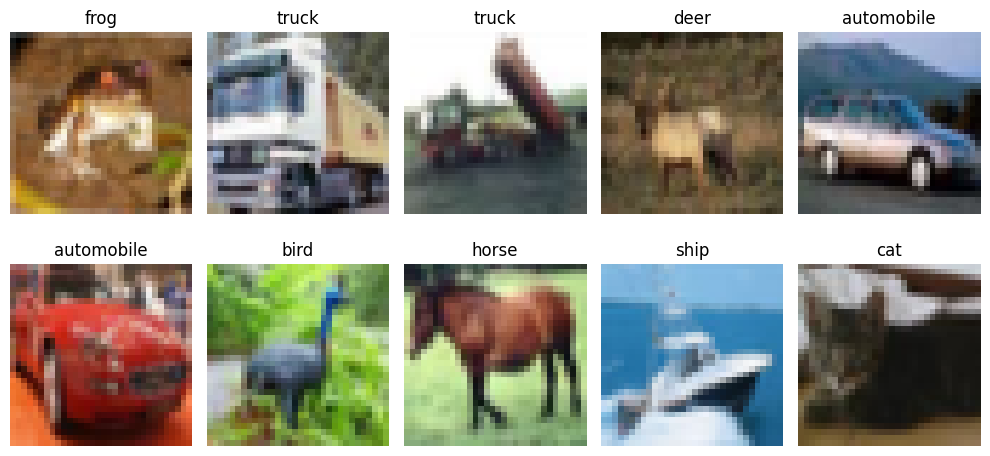

In [21]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [22]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
**why CNN is better for images**.

In [18]:
ann_model = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(1024, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 66ms/step - accuracy: 0.2862 - loss: 1.9696 - val_accuracy: 0.3320 - val_loss: 1.8252
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.3566 - loss: 1.7775 - val_accuracy: 0.3404 - val_loss: 1.8155
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.3782 - loss: 1.7321 - val_accuracy: 0.3614 - val_loss: 1.7791
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.3835 - loss: 1.7172 - val_accuracy: 0.3374 - val_loss: 1.8163
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 66ms/step - accuracy: 0.3860 - loss: 1.7096 - val_accuracy: 0.4040 - val_loss: 1.6596
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 66ms/step - accuracy: 0.3959 - loss: 1.6860 - val_accuracy: 0.4274 - val_loss: 1.6096
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.3989 - loss: 1.6838 - val_accuracy: 0.3910 - val_loss: 1.6851
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.4024 - loss: 1.6629 - 

In [23]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)
ann_model.summary()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4619 - loss: 1.4904
ANN Test Accuracy: 0.461899995803833


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,555,200 (44.08 MB)

 Trainable params: 3,850,410 (14.69 MB)

 Non-trainable params: 3,968 (15.50 KB)

 Optimizer params: 7,700,822 (29.38 MB)

#  Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [29]:
cnn_model = models.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 138s 192ms/step - accuracy: 0.4611 - loss: 1.5575 - val_accuracy: 0.5944 - val_loss: 1.1426
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 191ms/step - accuracy: 0.6268 - loss: 1.0625 - val_accuracy: 0.6114 - val_loss: 1.1563
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 190ms/step - accuracy: 0.6856 - loss: 0.9013 - val_accuracy: 0.6640 - val_loss: 0.9506
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 192ms/step - accuracy: 0.7269 - loss: 0.7898 - val_accuracy: 0.6958 - val_loss: 0.8964
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 189ms/step - accuracy: 0.7566 - loss: 0.7010 - val_accuracy: 0.7402 - val_loss: 0.7757
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 190ms/step - accuracy: 0.7838 - loss: 0.6311 - val_accuracy: 0.7458 - val_loss: 0.7431
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 147s 196ms/step - accuracy: 0.8011 - loss: 0.5720 - val_accuracy: 0.7096 - val_loss: 0.8808
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 194ms/step - accuracy: 0.8194 -

In [30]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.7354 - loss: 0.7627
CNN Test Accuracy: 0.7354000210762024


##  Compare Learning Curves ANN VS CNN

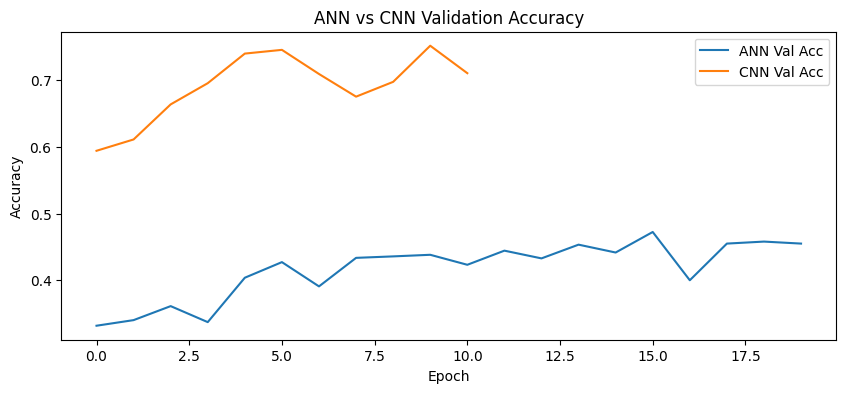

In [31]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

## Training Strategy Upgrade: Data Augmentation


In [55]:
data_augmentation = tf.keras.Sequential([layers.RandomFlip("horizontal")], name="augmentation")
aug_cnn_model = models.Sequential([
    layers.Input(shape=(32,32,3)),
    data_augmentation,
    layers.Conv2D(32,3,padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3,padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(128,3,padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(256,activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10,activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
)
#I had to removed early stopping because it stopped at epochs 5 everytime and the accuracy dropped by 20% compared to CNN above.


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 136s 188ms/step - accuracy: 0.4528 - loss: 1.5711 - val_accuracy: 0.5944 - val_loss: 1.1367
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 187ms/step - accuracy: 0.6033 - loss: 1.1162 - val_accuracy: 0.2948 - val_loss: 2.1156
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 131s 187ms/step - accuracy: 0.6691 - loss: 0.9463 - val_accuracy: 0.7012 - val_loss: 0.8368
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 132s 187ms/step - accuracy: 0.7044 - loss: 0.8482 - val_accuracy: 0.7220 - val_loss: 0.7904
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 132s 187ms/step - accuracy: 0.7255 - loss: 0.7847 - val_accuracy: 0.5934 - val_loss: 1.2691
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 134s 190ms/step - accuracy: 0.7475 - loss: 0.7257 - val_accuracy: 0.6982 - val_loss: 0.8657
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 188ms/step - accuracy: 0.7665 - loss: 0.6776 - val_accuracy: 0.7444 - val_loss: 0.7421
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 188ms/step - accuracy: 0.7824 -

In [56]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)

print("CNN+Aug Test Accuracy:", aug_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.7805 - loss: 0.6896
CNN+Aug Test Accuracy: 0.7804999947547913


#  Final Comparison Table

In [57]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN","CNN+Augmnetation"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc,aug_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4619
1,CNN,0.7354
2,CNN+Augmnetation,0.7805
